# Actividad 10 – Detección de bordes

**Objetivo**: usar Canny correctamente.

En esta actividad vamos a:
1. Cargar una imagen
2. Convertir a escala de grises
3. Aplicar GaussianBlur (reducir ruido)
4. Aplicar Canny
5. Probar distintos valores de umbral

## 1. Importar librerías necesarias

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Configurar matplotlib para mostrar imágenes en el notebook
%matplotlib inline

## 2. Cargar imagen

Cambia la ruta por la ubicación de tu imagen.

✓ Imagen cargada correctamente


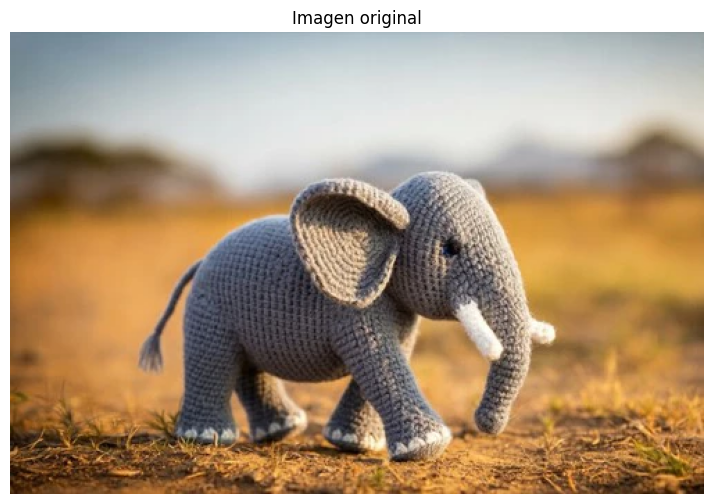

In [2]:
# Cargar la imagen
imagen = cv2.imread('imagen.webp')

# Verificar que la imagen se cargó correctamente
if imagen is None:
    print("Error: No se pudo cargar la imagen. Verifica la ruta del archivo.")
else:
    print("✓ Imagen cargada correctamente")
    
    # Mostrar la imagen original
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(imagen_rgb)
    plt.axis('off')
    plt.title('Imagen original')
    plt.show()

## 3. Convertir a escala de grises

Canny requiere una imagen en escala de grises.

✓ Imagen convertida a escala de grises
  Dimensiones originales: (333, 500, 3)
  Dimensiones en gris:    (333, 500)


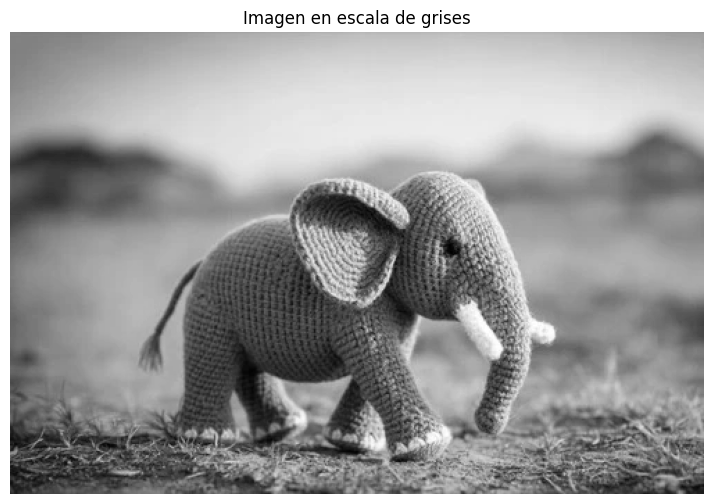

In [3]:
# Convertir a escala de grises
imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

print("✓ Imagen convertida a escala de grises")
print(f"  Dimensiones originales: {imagen.shape}")
print(f"  Dimensiones en gris:    {imagen_gris.shape}")

plt.figure(figsize=(10, 6))
plt.imshow(imagen_gris, cmap='gray')
plt.title('Imagen en escala de grises')
plt.axis('off')
plt.show()

## 4. Aplicar GaussianBlur

Es importante aplicar desenfoque gaussiano antes de Canny para reducir el ruido y evitar falsos bordes.

✓ Desenfoque gaussiano aplicado con kernel (5, 5)


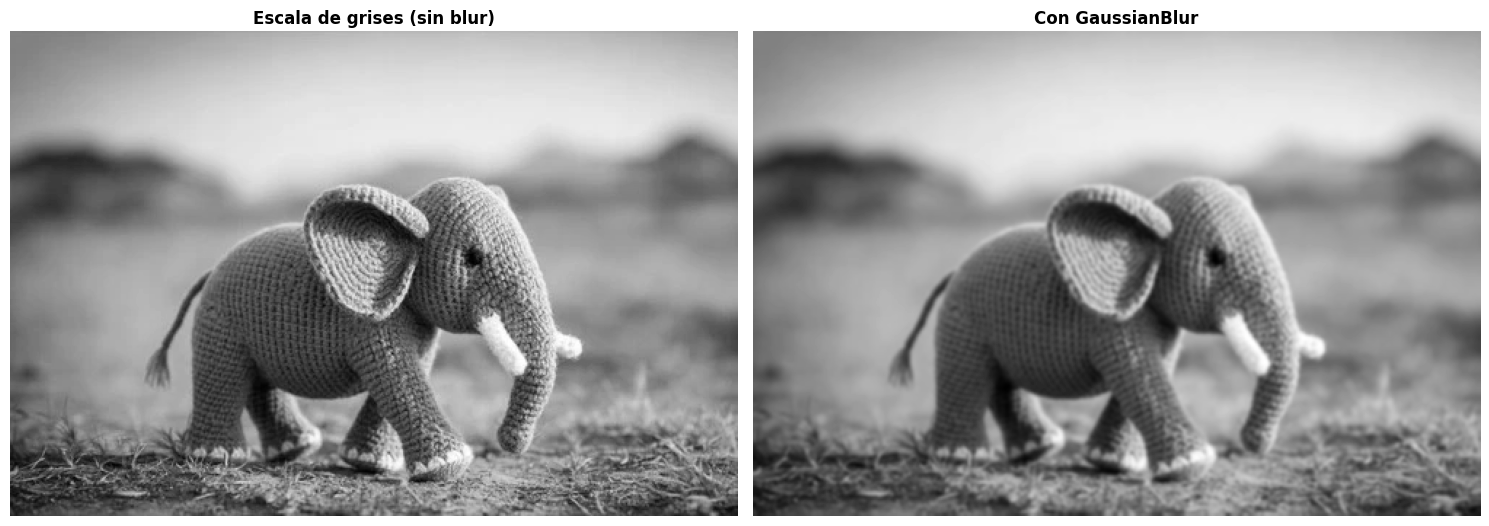

In [4]:
# Aplicar desenfoque gaussiano
kernel_size = (5, 5)
imagen_blur = cv2.GaussianBlur(imagen_gris, kernel_size, 0)

print(f"✓ Desenfoque gaussiano aplicado con kernel {kernel_size}")

# Comparar antes y después del blur
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].imshow(imagen_gris, cmap='gray')
axes[0].set_title('Escala de grises (sin blur)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(imagen_blur, cmap='gray')
axes[1].set_title('Con GaussianBlur', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 5. Aplicar Canny con distintos umbrales

Vamos a probar diferentes valores de umbral para ver cómo afectan a la detección de bordes.

✓ Canny aplicado con umbrales (30, 100)
✓ Canny aplicado con umbrales (50, 150)
✓ Canny aplicado con umbrales (100, 200)
✓ Canny aplicado con umbrales (150, 250)


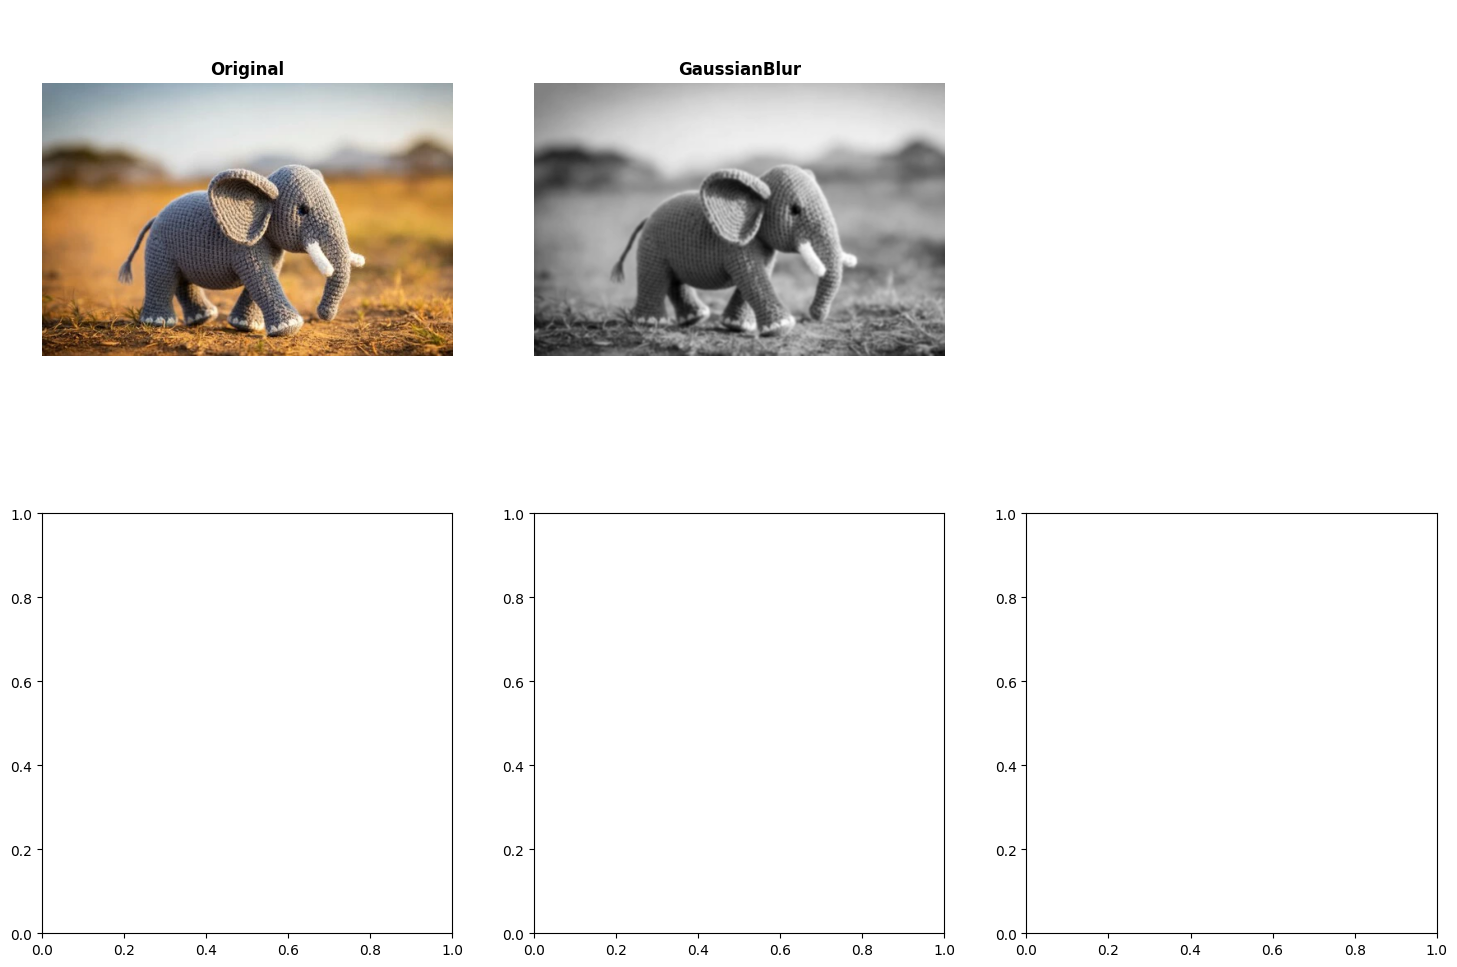

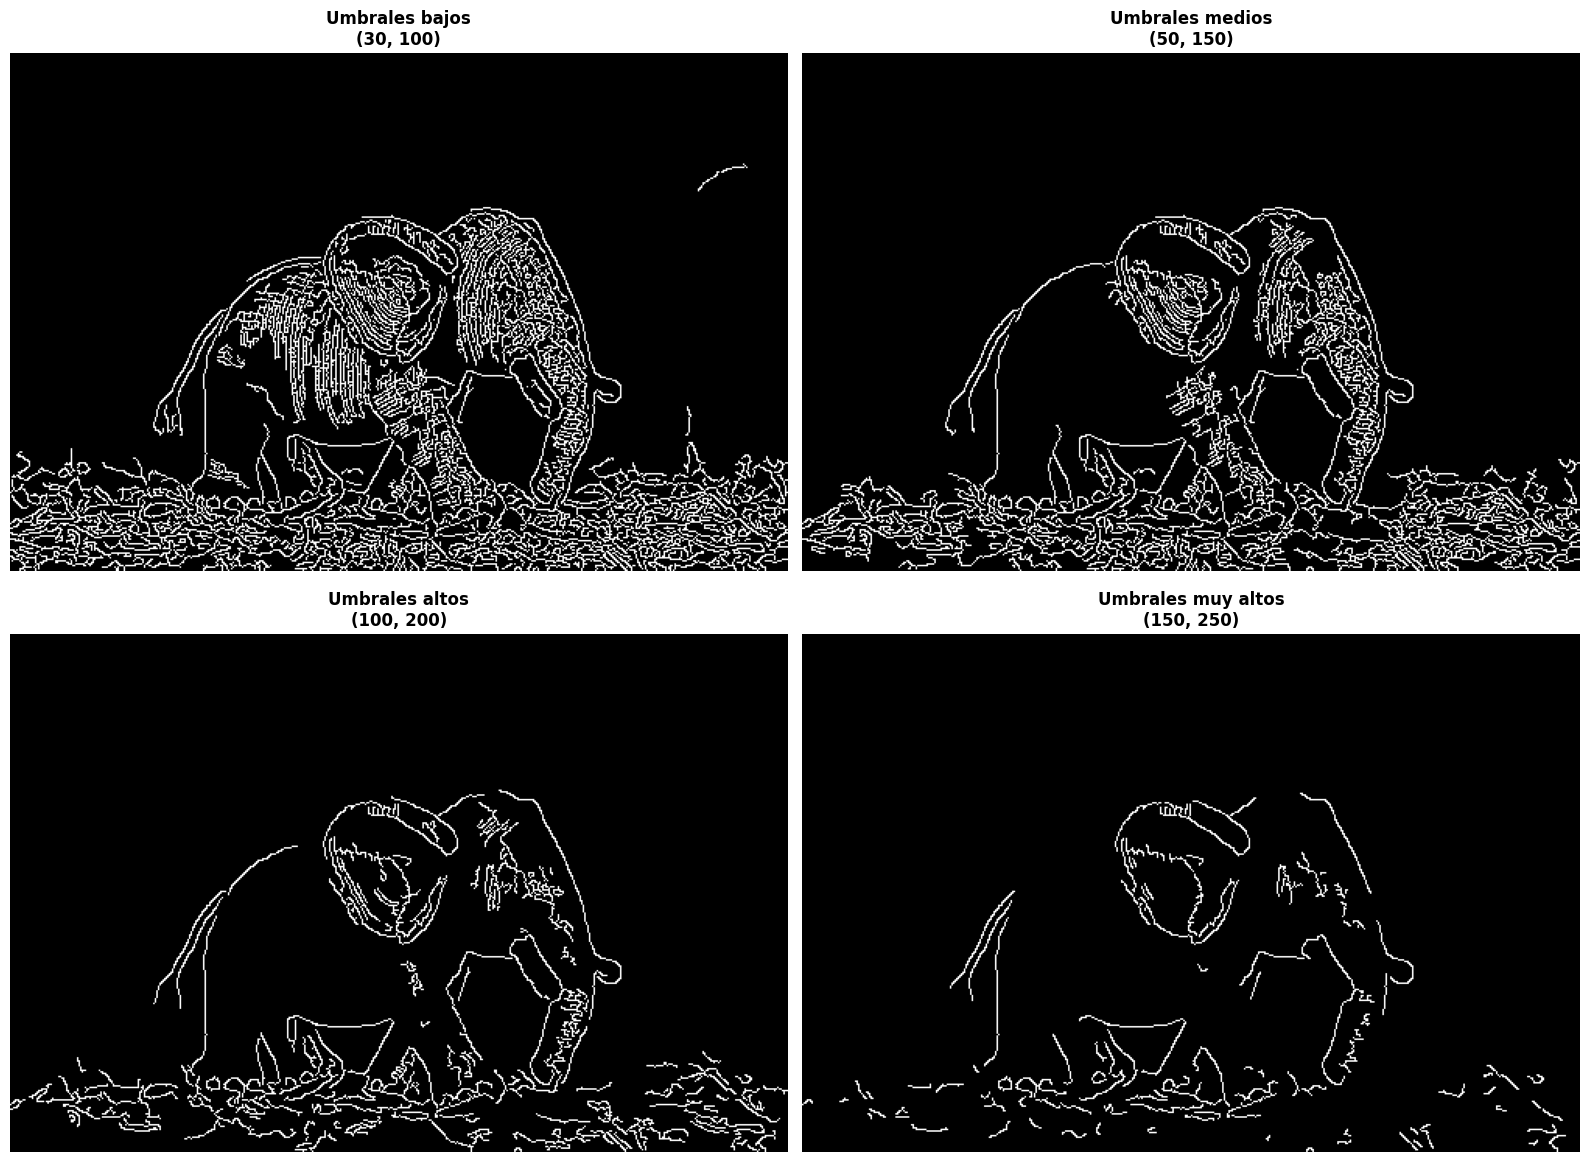


OBSERVACIONES:
- Umbrales bajos: detectan más bordes (más sensibles)
- Umbrales altos: detectan menos bordes (más selectivos)
- El umbral óptimo depende de la imagen y el objetivo


In [5]:
# Probar diferentes umbrales
# Formato: (umbral_minimo, umbral_maximo, descripción)
configuraciones = [
    (30, 100, "Umbrales bajos\n(30, 100)"),
    (50, 150, "Umbrales medios\n(50, 150)"),
    (100, 200, "Umbrales altos\n(100, 200)"),
    (150, 250, "Umbrales muy altos\n(150, 250)")
]

# Crear figura con múltiples subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Mostrar imagen original
axes[0, 0].imshow(imagen_rgb)
axes[0, 0].set_title('Original', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Mostrar imagen con blur
axes[0, 1].imshow(imagen_blur, cmap='gray')
axes[0, 1].set_title('GaussianBlur', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# Ocultar el subplot que no se usa
axes[0, 2].axis('off')

# Aplicar Canny con diferentes umbrales
for idx, (umbral_min, umbral_max, descripcion) in enumerate(configuraciones):
    bordes = cv2.Canny(imagen_blur, umbral_min, umbral_max)
    
    # Calcular posición en la cuadrícula
    fila = 1 + idx // 2
    columna = idx % 2
    
    if fila < 2 or columna < 3:  # Ajustar para la cuadrícula 2x3
        row = 1
        col = idx
        if idx >= 2:
            row = 1
            col = idx
        
        # Posiciones actuales: fila 1 tendrá 4 imágenes Canny
        # Como tenemos 2x3, mostramos solo 4 (2 en segunda fila, 2 en tercera fila)
    
    # Mejor distribución: row 1 cols 0,1,2 y row 2 cols 0,1,2
    # Pero solo tenemos 4 configs, así que: (1,0), (1,1), (1,2), y necesitamos una más
    # Voy a cambiar la estructura a 2x2 para las 4 configuraciones
    
# Mejor crear una figura diferente
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))

for idx, (umbral_min, umbral_max, descripcion) in enumerate(configuraciones):
    bordes = cv2.Canny(imagen_blur, umbral_min, umbral_max)
    
    fila = idx // 2
    columna = idx % 2
    
    axes2[fila, columna].imshow(bordes, cmap='gray')
    axes2[fila, columna].set_title(descripcion, fontsize=12, fontweight='bold')
    axes2[fila, columna].axis('off')
    
    print(f"✓ Canny aplicado con umbrales ({umbral_min}, {umbral_max})")

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("OBSERVACIONES:")
print("="*60)
print("- Umbrales bajos: detectan más bordes (más sensibles)")
print("- Umbrales altos: detectan menos bordes (más selectivos)")
print("- El umbral óptimo depende de la imagen y el objetivo")
print("="*60)